# 심볼릭 계산(Symbolic computation)

수치적인 방법과 해석적인 방법을 가르는 큰 차이는 변수를 어떻게 바라볼까에 있습니다.

수치적인 방법에서는 변수들을 결국 진짜 그 숫자로 바라보고, 그 숫자간의 계산에 초점을 맞췄었죠.

파이썬에서 지금까지 다룬 이야기들도 모두 이러한 수치적 계산의 이야기였습니다.

하지만 놀랍게도 파이썬에서는 수치적인 것 뿐 아니라, 해석적인 계산도 가능한데요, 이를 심볼릭 계산이라고 합니다.

심볼릭 계산은 말 그대로 우리가 공책을 펼치고 손으로 계산하는 수학에서 사용하는 상징적인 기호들을 이용한 계산을 의미합니다.

이번 포스팅에서는 **심파이**(Sympy)라고 불리는 Computational Algebra System을 이용한 심볼릭 계산을 조금 다뤄보려고 합니다.

계속 설명한대로 해석적인 방법은 한계가 있습니다. 그래서 우리가 계속 수치적인 방법을 공부하는건데요,

동시에 수치적 방법도 한계가 있습니다. 해석적으로 생각하는 값을 정확하게 표현할 수 없으니까요.

우리는 각자의 강점을 모으고, 각자의 단점을 줄이기 위해 해석적인 대수 연산을 가능케하는 심파이라는 모둘을 활용할 수 있습니다.

In [1]:
import sympy as sy

## 심파이의 기본적인 구성 요소들

심파이의 가장 근본적인 객체들은 *상징*과 *표현*입니다.

상징은 수학적인 변수 및 상수(변수처럼 이름이 붙은)들, 이를테면 $x,y,t$ 등을 파이썬 객체로 표현할 수 있도록하는 객체이고,

표현은 이러한 상징들 및 상수, 연산들로 구성되는 수학적 표현 $x + 2$, $f(x) = 0$ 등을 파이썬 객체로 표현하기 위한 객체입니다.

우선 상징은 `sy.symbols()`로 생성이 가능합니다.

In [2]:
xsym = sy.symbols('x')
xsym

x

간단합니다. 저 괄호 안에 정의하고 싶은 변수를 넣어 상징들을 정의할 수 있습니다.

그리고 한 번에 여러 개의 변수를 정의하는거도 가능합니다 :    

In [3]:
xsym,ysym = sy.symbols('x,y')

# xsym
ysym

y

위 코드의 `xsym` 과 `ysym` 앞에 주석 기호 `#`를 뗐다가 붙였다가 하면서 번갈아가면서 한 번씩 실행시켜보시면 

위와 같은 방식으로 두 상징이 각각 정의됨을 알 수 있습니다. 

위와 같이 다중 할당으로 `sy.symbols()'의 안에 들어오는 놈은 콤마 혹은 공백이 있다면, 그 콤마/공백을 기준으로 복수의 상징을 정의해버립니다. 

근데 만약 위와 같이 다중 할당 `xsym, ysym`을 하지 않는다면, `symbols('x,y')`는 `(x,y)`의 형태로, 상징 `x`와 상징 `y`가 담긴 투플을 생성합니다.

In [4]:
x = sy.symbols('x,y')

print(type(x))

x[0] # 상징으로 구성된 투플이므로, 0번째에는 상징 x, 1번째에는 상징 y가 들어있음

<class 'tuple'>


x

우리는 이렇게 정의한 상징으로 기존에 사용하던 파이썬 기본 연산들을 통해서 다음과 같이 표현을 정의할 수 있습니다.

In [5]:
expr = xsym**2 + ysym
expr

x**2 + y

이 경우, 우리의 표현은 두 상징을 더하는 표현이므로, `Add`라는 형태의 표현 객체로 정의됩니다 :

In [6]:
type(expr)

sympy.core.add.Add

일반적으로 우리는 상징들을 담는 변수의 이름을 상징들과 완전 동일하게 정의합니다 :

In [7]:
x, y = sy.symbols('x, y') # 변수 x에 상징 x를, 변수 y에 상징 y를
x**2 + y

x**2 + y

하지만 실제로 변수 `x`와 상징 `x`를 개념적으로 구분해서 생각하는 게 바람직합니다.

위의 코드에 `x`라는 (파이썬의) 변수에는 `x`라는 상징이 들어있고, 이 둘을 같은 놈으로 생각하면 안된다는겁니다.

In [8]:
x = sy.symbols('x')
y = sy.symbols('x')

x == y

True

결국 위와 같이 `x`나 `y`나 두 변수는 같은 상징 `x`를 담기 떄문에, 위와 같이 비교시 심파이는 `True`를 반환합니다.

중요한건 그 변수의 이름이 아니라. 안에 들어있는 친구라는거죠. 구분을 잘 하셔야합니다.

여튼 우리는 저렇게 변수를 정의한다면, 저 변수로 구성되는 표현 형태의 함수를 다음과 같이 정의할 수 있습니다.

In [9]:
f = x*x+3*x+y
g = x-y
sy.Tuple(f,g) # (f,g) 형태의 벡터 함수 표현

(x**2 + 4*x, 0)

`sy.Tuple()`은 여러 표현들의 투플을 생성합니다. 이를 이용하면 아래와 같이 복잡한 벡터 함수들도 표현 가능합니다.

In [10]:
sy.Tuple(f**g, f+g, f-g, f*g, f/g)

(1, x**2 + 4*x, x**2 + 4*x, 0, zoo*(x**2 + 4*x))

기본적으로 상징들은 어떠한 제한 조건이 없는, 정해지지 않은 수학적 변수들을 표현합니다.

하지만 우리는 수학에서 저 변수들의 값의 범위(실수, 양수, 정수 등) 등을 제한하기도 하는데요, 이는 상징을 생성하며 다음과 같이 가능합니다.

In [11]:
xreal = sy.symbols('x', real=True) # 실수 범위의 제한

위에서 우리는 `real`로 실수 범위로 제한을 할 수 있는데요, 그 외에도 `even`, `odd`, `positive`, `negative`, `integer`, `complex` 등을 사용할 수 있습니다.

물론 `False`를 입력하셔도 됩니다. 예를 들어 `negative = False`를 한다면, 그 변수는 음이 아닌 수가 됩니다.

이러한 조건을 거는걸 심파이에서는 가정(Assumption)이라 합니다. 따라서 `positive` 등의 친구들도 가정 속성(Assumption attribute)이라 합니다.

또한 여러 조건을 동시에 걸 수도 있습니다. `positive = True`에다가 `integer = True`를 거는거처럼요. 

가정 속성들은 그 자체로는 사실 상징일 뿐이고 아무런 의미가 없는 파이썬 상징들에 수학적 맥락을 제공하는 역할을 합니다.

나중에 우리는 이를 식의 단순화, 극한값 계산, 적분을 이용할 때 자주 사용합니다. 또한 수학적 공간을 표현하기 위해서도 사용합니다.

위에서 우리는 상징을 담은 변수들을 비교하는걸 다뤘었는데요, 상징 비교 시 이 가정 속성이 다르면 서로 다른 상징으로 인식됩니다 :

In [12]:
xreal = sy.symbols('x', real=True) # 실수 범위의 제한
x = sy.symbols('x')
xreal == x

False

## 수학 랜더링

심파이는 결국 수학 공식들을 표현하고, 위에서부터 보신다면 심파이 객체가 출력될 시 좀 수학적인 방식으로 랜더링되어 출력됨을 알 수 있습니다.

이는 주피터 노트북의 기능으로, 별 다른 문제가 없는 경우에는 위에서 계속 보신대로 $\LaTeX$의 방식대로 상징 및 표현을 렌더링하는데요,

간혹 이게 실패하는 경우가 있습니다. 이럴 때에는 다음 함수를 사용하면 모든 상징 및 표현이 랜더링됩니다.

In [13]:
sy.init_printing()
expr, f/g, f**g

물론 이게 항상 저렇게 멋있게 나오는건 아니구요, 환경에 맞게 설정되어 나오는겁니다. 주피터 노트북에서는 저렇게 라텍스 방식으로 랜더링됩니다.

다른 환경이라면 그 환경에 맞는 다른 방식으로 랜더링될 수도 있습니다.

## 상징화 함수 S

파이썬의 기본적인 변수와 상징들은 기본적으로 서로 다른 대상이므로, 

떄로는 상징적인 연산 과정에서 파이썬의 변수로서가 아닌 상징으로서의 연산임을 확실하게해줘야 할 필요가 있습니다.

이를 위해서 우리는 파이썬의 객체를 상징으로 만드는 상징화 함수 `S()`를 사용합니다.

In [14]:
from sympy import S

뭔가 말을 어렵게 설명했는데, 결국 문제는 `SymPy`가 상징으로서 뭔가를 다루기 이전에, 파이썬이 그걸 상징이 아닌 파이썬의 객체로 가로채버린다는겁니다.

예를 들어서 다음과 같은 표현을 정의했을 때,

In [15]:
x = sy.symbols('x')

expr = 1/3*x
expr

그 결과물은 `0.333333...`라는 파이썬의 `float`형 객체와, 상징 $x$를 저렇게 곱한 형태가 됩니다.

그거도 그리 나쁘진 않지만, 우리는 되도록이면 저 `1/3`조차  $\frac{1}{3}$라는 상징으로서 다루고 싶은거에요.

이 경우, 우리는 `S(1)/3`를 `x`에 곱하여 다음과 같이 표현을 생성할 수 있습니다.

In [16]:
expr = S(1)/3*x
expr

우리는 이렇게 상징들을 정의해서, 그걸로 연산을 하고 이런 저런 프로그래밍을 할건데, 그 과정에서 등장하는 모두가 상징임을 유지하기 위한 함수인거죠.

왜 근데 `S(1/3)`이 아니라 `S(1)/3`인지 궁금하실 수 있는데요, 여기서는 연산의 차이가 있기 떄문입니다.

`S(1/3)`은 일단 안에 있는 `1/3`을 계산하고, 그 이후에 그걸 상징화합니다. 따라서 결국 `0.33333333333`이라는 놈이 상징화되어버립니다.

이건 우리가 원하는 방향이 아니죠. 따라서 우선 `S(1)`로 1을 상징화하고, 이걸 3으로 나눈 $\frac{1}{3}$이라는 상징을 정의하는거에요.

저렇게 `int`나 `float`형의 데이터가 함수 `S()`의 안에 들어가면, 그 놈은 상징, 그 중에서도 `SymPy`가 관리하는 특이한 수치형 상징으로 저장됩니다.

마찬가지로 숫자 대신에 상징을 넣어서,

```python
x = S('x')
```
라고 정의해도 됩니다. `symbols()`를 사용할 필요 없이요. 그러면 자동으로 `x`에는 $x$라는 상징이 저장됩니다.

`S()`는 만능이에요. 상징 뿐 아니라 표현도 다음과 같이 만들어낼 수 있습니다.
```python
expr = S('sin(x)**2 + y')
```

In [17]:
expr = S('sin(x)**2 + y')
print(type(expr))
expr

<class 'sympy.core.add.Add'>


보시다시피 `S()`의 함수는 매우 다양한 역할을 수행할 수 있으며, 얘가 가능한 모든 능력은 다음 코드를 실행시키시면 확인 가능합니다.

In [18]:
help(sy.sympify) # 함수 S의 풀네임은 sy.sympify()이고, S()는 그 함수의 단축키 같은겁니다.

Help on function sympify in module sympy.core.sympify:

sympify(
    a,
    locals=None,
    convert_xor=True,
    strict=False,
    rational=False,
    evaluate=None
)
    Converts an arbitrary expression to a type that can be used inside SymPy.

    Explanation

    It will convert Python ints into instances of :class:`~.Integer`, floats
    into instances of :class:`~.Float`, etc. It is also able to coerce
    symbolic expressions which inherit from :class:`~.Basic`. This can be
    useful in cooperation with SAGE.

    .. warning::
        Note that this function uses ``eval``, and thus shouldn't be used on
        unsanitized input.

    If the argument is already a type that SymPy understands, it will do
    nothing but return that value. This can be used at the beginning of a
    function to ensure you are working with the correct type.

    Examples

    >>> from sympy import sympify

    >>> sympify(2).is_integer
    True
    >>> sympify(2).is_real
    True

    >>> sympify(2.

더 나아가 함수 `S`에는  우리가 자주 사용하는 상징들이 속성으로 들어가있습니다 :

In [19]:
S.Half, S.Pi, S.Exp1, S.Zero, S.One, S.Infinity, S.NegativeInfinity

## 유리수

SymPy로 우리는 결국 해석적인 계산을 하고 있는건데요, 이에 따라서 수치적인 계산에서 발생하는 오차가 전혀 발생하지 않습니다.

예를 들어 `1/3`이라는 유리수는 파이썬에서 수치적으로 `0.333333...333` 형태의 유한 소수로 다뤄지는데요,

SymPy로 상징 계산을 이어간다면, 위에서 한대로 `S(1)/3` 등의 방법으로 $\frac{1}{3}$이라는 분수 그 자체를 구현할 수 있기 떄문에 오차가 없어요.

유리수는 `sympy.Rational(q,p)`함수로 생성할 수 있습니다.

In [20]:
xr = sy.Rational(2, 3)
yr = sy.Rational(3, 4)
xr, yr, xr + yr # 계산도 가능합니다.

`sympy.Rational`는 결국 분수를 상징으로 사용하기 위한 객체입니다.

이 유리수 객체는 계산이 가능한 만큼, 약분이라는 개념도 존재합니다 :

In [21]:
sy.Rational(2, 3) == sy.Rational(4, 6)

True

저렇게 유리수로도 생성할 수 있으나, 우리가 위에서 헀던대로 심파이의 정수 `S(1)`을 정수로 나누거나,

심파이의 정수끼리의 나눗셈을 연산하는 방법으로도 유리수 객체를 생성할 수 있습니다.

In [22]:
S(1)/S(3), S(1)/3, 1/S(3) # 모두 다 sympy.Rational의 객체입니다.

**주의할 점**

위에서도 본대로 `S(1/3)`은 우선 `1/3`을 파이썬의 `float` 형태인 `0.33333...333`으로 계산한 후 `S()`를 사용하기 떄문에,

`S(1/3)`은 $0.333...33$이라는 모양의 상징이 되고, 우리가 원하는 $\frac{1}{3}$을 얻을 수 없습니다.

무엇보다도 이렇게 파이썬 `int`간의 나눗셈을 상징화한 `S(1/3)` 같은 친구는 유리수 `sympy.Rational`이 아닌 부동 실수 `sympy.Float` 로 저장됩니다.

In [23]:
type(S(1/3))

sympy.core.numbers.Float

## 복소수

위에서도 보셨다시피 SymPy에는 정수, 유리수, 실수(`sympy.Float`)를 위한 객체들이 다 있습니다.

하지만 복소수에는 복소수만을 위한 객체는 따로 없구요, 대신에 허수 단위 $i$를 의미하는 객체 `I`가 존재합니다.

In [24]:
from sympy import I
I

복소수들은 $a + bi$꼴로 표현되는데요, 이걸 그대로 사용하시면 됩니다. 다음과 같이요.

In [25]:
3 + 4*I

이렇게 하면 심파이는 3이라는 `sympy.Integer`과, `I`에 4를 곱한 놈을 더한 `3 + 4I`라는 sympy.Add 객체(표현의 일종)를 생성합니다.

임의의 복소수 $z$가 실수 $a,b$에 대해 $z = a+bi$를 만족한다면, 우리는 $z$의 실수부를 a라하며, $\text{Re} z := a$라 표기합니다.

그리고 마찬가지로 $b$는 허수부라고 하며, $\text{Im} z := b$라고 합니다.

이 $\text{Re},\text{Im}$은 복소수 $z$를 받아서, 실수로 대응시키는 함수의 일종으로 생각할 수 있는데요,

이 함수들은 `sympy`에서도 `sympy.re()`, `sympy.im()`의 함수로 정의되어 있습니다.

In [26]:
sy.re(3 + 4*I)

그리고 복소수에는 절대값 개념도 있는데요, 이건 그냥 파이썬 기본 내장 함수 `abs()`를 사용하시면 됩니다.

기본적으로 SymPy의 표현 객체에는 `abs()`가 덕 타이핑되어 있어서, 자동으로 우리가 원하는 복소수의 절대값도 모두 계산해줍니다 :

In [27]:
abs(3+4*I)

## 치환과 평가(Substitution and Evaluation)

수치적 과정은 오차와의 싸움입니다. 컴퓨터는 우리가 생각하는 실수(무한 소수) 형태의 데이터를 정확히 다루지 못하기 때문에,

어느 정도의 절삭을 허용한 근사치로 우리가 충분하다고 느끼는 정도의 오차를 감안하여 계산을 하는거죠.

그리고 이 수치적인 과정에서 발생하는 오차는 계산 단계가 복잡하면 복잡할수록 더 많이 발생합니다.

예를 들어서 $\frac{1}{3}*2*\frac{1}{6}$을 계산한다면, 우선 $\frac{1}{3}$을 수치적으로 $0.333....33$의 유리수로 근사해서 다루며,

2는 괜찮지만 $\frac{1}{6}$도 마찬가지로 근사된 값을 사용하게 되어, 결국 실제 결과물 $\frac{1}{9}$과 오차가 꽤나 커집니다.

이 정도 간단한 곱셈이면 그나마 낫지만, 컴퓨터로 하는 계산은 훨씬 복잡하니 계산 과정에서 수치적 오차는 계속해서 더해지겠죠.

따라서 모든 과정을 수치적인 계산으로 때려버린다면, 그 중간 중간에 항상 부동소수 오차나 캔셀레이션 등 수치적 과정의 필연적인 오차들이 발생합니다.

우리가 지금 sympy를 이용하는 목적은 결국 컴퓨터로 해석학적인 계산을 시켜서, 진짜 마지막 계산식 전의 계산들은 모두 상징들로 남겨놓고,

가장 마지막에 나온 결과에 수치를 직접 넣어서 좀 더 정확한 수치적인 결과를 얻기 위함이라고 할 수 있습니다.

그니까 우리는 지금까지 다룬 저 표현들에 값을 넣어서 평가하거나, 아니면 저 표현에 등장하는 특정 부분을 치환하는 방법이 필요합니다.

우리는 특정 표현 `expr`의 상징에 직접 구체적인 수치를 넣거나, 다른 상징으로 치환하기 위해 메소드 `subs()`를 사용합니다.
~~~python
expr.subs(symbol, value)
~~~

해당 메소드는 `expr`에 등장하는 상징 `symbol`을 `value`로 바꾼 놈을 반환합니다.

`value`는 또 다른 상징, 혹은 수치형 상징(sympy.Integer 등), 심지어는 또 다른 표현이 올 수 있습니다.

우리가 수학에서 알고 있는 그 치환을 수행하는거에요.

참고로 SymPy의 표현들은 불변(Immutable)입니다. 따라서 위의 메소드를 수행하더라도 치환 전의 `expr`은 그대로 남아있습니다.

그 이유는 간단합니다. 수학에서도 $f(x) =x$라는 식이 있을 때, $x = 10$을 넣는다고 $f(x)$가 변하는건 아니잖아요? 그래서 우리는 원형을 남겨놓습니다.

그래서 치환 전의 `expr`과, `expr.subs(symbol, value)`는 별개로 생각하셔야 합니다.

따라서 치환된 표현을 얻고 싶으시다면 따로 하나 더 표현을 담을 변수를 정의하셔야합니다. 

In [28]:
x,y = S('x,y')
expr = (16*x - 13)**3
expr.subs(x, 1), expr.subs({x: 4}), expr.subs(x, y*x**2) # 왼쪽엔 expr에 1을 넣은 놈, 중간엔 4를 넣은 놈, 오른쪽엔 x를 x^2y로 바꾼 놈

In [29]:
expr # 기존의 표현은 안 바뀜

그리고 당연히 `subs()` 메소드를 이용하여 둘 이상의 상징을 다중 치환하는거도 할 수 있습니다.

이 때는 투플로 구성된 리스트나 딕셔너리 등이 위 매개변수의 `symbol,value` 대신에 들어갑니다. 보통 가독성이랑 속도 떄문에 딕셔너리를 자주 사용합니다.

~~~python
dictionary = {symbol1: value1, symbol2: value2, ...}
expr.subs(dictionary)
~~~

그 외에도 체이닝이라고 불리는 방법도 사용하실 수 있긴 한데요, 보통 너무 길어져서 사용하지 않습니다 :

```python
expr.subs(symbol1,value1).subs(symbol2,value2) ...
```

두 개 정도 치환할거면 괜찮은데, 그보다 많이 치환하면 그냥 딕셔너리가 낫습니다.

In [30]:
x,y,z = S('x,y,z')

expr = x + y
dic = {x : y, y : z} # x를 z로, y를 z로

expr.subs(dic)

위의 다중 치환은 순서대로 `expr`의 $x$를 $y$로, $y$를 $z$로 바꿉니다. 따라서 다음의 과정으로 치환이 진행됩니다.

$$
x+y \quad \overset{x \to y}{\Rightarrow}\quad y + z \quad \overset{y \to z}{\Rightarrow} \quad z + z = 2z
$$

딕셔너리에 들어간 순서대로 치환이 수행되는거죠. 근데 간혹 이렇게 순차적으로 말고 동시에 치환이 필요할 수 있는데요, 이는 다음과 같이 가능합니다.

In [31]:
x,y,z = S('x,y,z')

expr = x + y
dic = {x : y, y : z} # x를 z로, y를 z로, 근데 동시에

expr.subs(dic, simultaneous = True)

`subs()`의 매개변수 `simultaneous`를 `True`로 켜준다면, 말 그대로 치환이 동시에 진행됩니다 :

$$
x+y \overset{x\to y,\; y\to z}{\Rightarrow} y + z
$$

### 상징들의 함수와 표현들의 수치적 평가

상징들로 이뤄진 함수 및 표현들에 구체적인 수치를 넣어서 평가하는 방법은 다양하게 있습니다.

위에서 다룬 `subs()` 메소드도 이런 수치를 넣는다는 개념을 어느 정도 수행할 수 있습니다.

`subs()`로 특정 상징들을 우리가 원하는 숫자로 치환하면 되니까요.

하지만 주의할 점은, `subs()`는 아직 해석적인 영역에 있고, 수치적인 영역까지 가지는 못한다는겁니다.

만약 어떤 함수나 표현에 등장하는 상징들을 모두 구체적인 숫자로 `subs()`하면 결과물은 어쨌든 숫자가 되긴 할텐데요,

그 숫자는 어디까지나 수치적이지 않습니다. 예를 들어 $e^2$라는 표현이 들어있다면, 이 표현은 그대로 이렇게 해석적인 형태로 표현됩니다

실제로 숫자를 넣은 수치적인 결과를 얻고 싶다면 `evalf()`라는 메소드를 사용하셔야합니다.

~~~python
expr.evalf(n)
~~~

헷갈리시면 안됩니다. 마치 저 `n`의 자리에 우리가 `expr`를 평가하고 싶은 수치가 들어갈거 같지만, `n`은 수치적 결과로 표현할 소수점 아래 자리의 개수입니다.

In [32]:
expr = x**2 + sy.exp(x) # x^2 + e^x
expr.subs(x, 2)  # 2^2 + e^2 = 4 + e^2

이 단계에서 `expr.subs(x,2)`는 아직 $4 + e^2$라는 해석적인 모습을 간직합니다. 여기서 우리는 `evalf(50)`를 적용하여, 다음과 같이 수치를 얻을 수 있습니다.

In [33]:
expr.subs(x, 2).evalf(50)

만약 `evalf()`가 적용되는 표현에 아직 치환되지 않은 상징이 있다면, 그 상징은 제외하고 나머지 놈들이 수치적으로 계산됩니다

In [34]:
expr = x**2 + sy.sin(y)
expr.subs(x,S(1)/3).evalf(20)

위에서 저는 우리의 목표가 해석적으로 표현된 놈으로 최종 형태를 만들어서, 마지막에 수치를 넣은 결과를 얻는 게 목적이라고 했었는데요,

`evalf()`가 비로소 이 마무리 단계에서 수치를 얻게 하는 역할을 하는 중요한 친구입니다.

위에서 우리는 `subs()`를 사용한 후 `evalf()`로 수치를 계산한 결과를 얻어냈는데요,

이는 `evalf()`의 파라미터로 치환 대상을 묶은 투플들의 리스트/딕셔너리를 넘겨주는 방식으로 `evalf()` 단독으로도 가능합니다.

```python
dictionary = {symbol1 : value1, symbol2 : value2, ...}
expr.evalf(n,dictionary)
```

In [35]:
expr = x**2 + sy.exp(x) # x^2 + e^x
expr.evalf(50, subs={x: 2})

보시다시피 `evalf()`의 결과물은 SymPy의 Float 형태의 객체입니다. 이 결과물은 수치적이지만, 컴퓨터의 문제(유한 자리만 다룰 수 있음)가

꽤 많이 해결된 형태라서요, 그냥 파이썬의 `float`을 사용하는거보단 훨씬 정확도가 높습니다.

In [36]:
float(expr.evalf(50, subs={x: 2})) # 실제로 타입 변환 시 위의 sympy.Float의 형태보다 정확성이 낮은 수치를 얻습니다.

## 조각별로 정의되는 함수(Piecewise defined function)

지금까지 우리는 표현 `expr`에다가 상징을 이용한 수식을 넣어서 함수를 생각했었습니다.

근데 함수들 중에서는 간혹, 이렇게 하나의 표현으로 구성되는 게 아니라, 범위에 따라 달라지는 다양한 표현으로 구성되는 경우도 있습니다.

예를 들어 실수 위의 부분 집합 $A\subset \mathbb{R}$에 대한 특성 함수 $\chi_A$는 다음과 같이 정의됩니다.
$$
\chi_A(x) := \begin{cases} 1 , & x \in A\\ 0, & x\not\in A \end{cases}
$$

이렇게 범위 별로 다른 형태로 정의되는 함수, 혹운 조건부 함수(Conditional function)를 조각별로 정의되는 함수라고 합니다.

이런 함수 개념은 SymPy의 표현 객체들 중 `Piecewise`라는 놈으로 구현이 가능합니다. 

~~~python
sy.Piecewise((expr1,cond1), (expr2,cond2), ... , (exprn,condn), (expr_last, True))
~~~

`Piecewise()`는 보시다시피 각 표현 `expr`과, 그 표현이 해당 함수를 설명할 수 있는 범위를 표현하는 `cond`의 여러 싸응로 구성됩니다.

`cond`는 Condition, 즉 조건이라는 이름답게 해당 표현이 설명할 범위를 부울 표현(논리값을 뱉어내는 표현)으로 표현합니다. 대부분 부등식이에요.

간혹 사용자의 실수 혹은 의도에 의해서 이 컨디션들이 겹쳐서, 복수의 표현이 모두 알맞은 경우가 있을 수 있는데요, 

이 때는 더 앞 쪽(왼 쪽)에 있는 표현이 해당 범위에서의 표현으로 선정됩니다.

그리고 위를 보시면 대충 느낌이 오실텐데요, 앞서 표현된 모든 조건을 제외한 경우의 표현을 위한 조건은 위와 같이 `True`라는 키워드로 지정합니다.

In [37]:
g = sy.Piecewise(
    (-x,   x < 0),
    (x,    x < 1), #설명한대로 조건이 겹치는 부분, 즉 x<0인 부분에서는 앞선 표현인 -x가  사용됨. 
    (x**2, True) # True가 온다면 설명한대로, 위의 설명대로 나머지 경우, 즉 x>=1인 경우를 의미함
)
g

⎧-x  for x < 0
⎪             
⎪x   for x < 1
⎨             
⎪ 2           
⎪x   otherwise
⎩             

In [38]:
g.subs(x, -S.Half), g.subs(x, S(1)/3), g.subs(x, 2)

## 단순화

컴퓨터 대수(Computation Algebra)의 엄청 중요한 기능 중 하나는 식의 단순화입니다.

우리의 목적이 최종 형태를 만들어서, 거기 수치를 넣는거였는데요, 이 최종 형태도 간단하면 간단할수록 수치적인 오차가 적겠죠?

따라서 우리는 표현을 이리 저리 만지고 바꿔서 단순화를 할 필요가 있습니다.

일단 SymPy에는 별도 명령을 하지 않아도 매우 자명한 단순화는 자기가 알아서 처리합니다.

예를 들어, $x + 1 + 2$는 $ x+3$으로, $2x + 3x$는 $5x$로 하는 등에요.

근데 이 "자명한" 단순화도, 정확히 뭐가 자명한지를 모르는 입장에서는 충분치 않죠. 실제로 이 자명한 단순화가 모든 단순화를 커버하지는 못합니다.

따라서 우리는 심파이에서 지원하는 단순화 도구를 구체적으로 알 필요가 있습니다.

단순화의 가장 일반적인 해결책은 메소드/함수 `simplify()`입니다. 이 놈은 다음과 같이 함수 및 메소드로 모두 사용 가능합니다.

~~~python
expr.simplify() # 메소드로서
~~~
~~~python
sympy.simplify(expr) # 함수로서
~~~

참고로 SymPy는 메소드/함수의 형태로 모두 사용 가능한 놈들이 많습니다. `simplify()`도 그 예시인데요, 이런 놈들은 메소드나 함수나 기능이 거의 똑같습니다.

물론 `subs()`처럼 메소드로만 사용 가능한 놈도 있고, 또 다른 친구들 중에선 함수로만 사용 가능한 친구들도 있긴합니다.

여튼 `simplify()`는 가능한 가장 단순한 형태가 되도록 미리 지정된 규칙에 따른 다양한 단순화 단계를 거쳐 나온 결과를 반환하게 됩니다.

이 때, "가장 단순하다"는 당연히 정확하지 않습니다. 뭐가 가장 단순한지는 다 다르니까요. 따라서 결과물이 여러 분들의 기대와는 좀 다를 수도 있습니다.

예를 들어 다음 $2 - \frac{2}{x^2-1}$를 단순화하라고 명령해보죠.

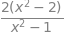

In [39]:
(2 - 2 / (x**2 - 1)).simplify()

그러면 그 결과물은 위와 같이 되는데요, 저 놈은 또 $\frac{2x^2-4}{x^2-1}$로도 표현 가능하고, $\frac{(x-\sqrt{2})(x+\sqrt{2})}{(x-1)(x+1)}$도 가능합니다.

아니면 애초에 원형인 $2- \frac{2}{x^2-1}$이 누군가의 입장에서는 가장 단순한 형태일 수도 있구요.

따라서 우리는 `simplify()` 한테 단순화를 모두 맡기는 대신, 구체적인 단순화 명령을 내릴수도 있습니다.

이 구체적인 단순화를 이제 경우를 나눠서 살펴볼게요.

### 삼각 함수 단순화

삼각비 및 삼각 함수는 계산 법칙들을 이용하여 단순화하는 함수는 다음과 같습니다.

~~~python
sy.trigsimp(expr)    # 단순화
sy.expand_trig(expr) # 전개하기
~~~

간단합니다. 윗 놈은 진짜 단순화를 하는 함수입니다. 입력된 표현을 삼각 함수/삼각비 계산 법칙에 따라 가장 복잡도가 적다고 판단되는 형태로 단순화합니다.

예를 들어서, 사인과 코사인 제곱의 합은 1임을 이용한다던지, $2\sin(x)\cos(x)$를 $\sin(2x)$로 만드는 등, 

일반적으로는 결과적으로 구성되는 항의 개수가 적어지도록 단순화합니다. 근데 이거도 일반적인거지, 항상 그런건 아니에요.

또 아래에 있는 저 친구는 삼각함수/삼각비의 공식에 따라서, 전개할 수 있는 경우의 수가 있다면 표현을 전개시킵니다. `trigsimp()`의 반대죠.

예를 들어 다음을 생각해볼게요.

In [40]:
f = x/(x+y)+y/(x+y)-sy.sin(x)**2-sy.cos(x)**2
f

이 놈을 단순화하면 결국 $1 - (\sin^2(x) + \cos^2(x)) = 1 - 1 = 0$이 되는데요, `trigsimp()`는 이런 단순화를 합니다.

In [41]:
sy.trigsimp(f)

반대로 `expand_trig()`는 식을 전개하는데, 이건 쉽게 생각해서 덧셈 법칙의 방향으로 식을 바꾼다고 생각하시면 됩니다.

덧셈 법칙 등에 의하면 $\sin(x+y)$가 있다면, 이걸 $\sin(x)$, $\cos(x)$, $\sin(y)$, $\cos(y)$로 표현할 수 있잖아요?

그걸 하는거에요 :

In [42]:
sy.expand_trig(sy.sin(x + y))

### 다항식 및 유리식의 단순화

삼각 함수 이전에 우리는 다항식과 유리식을 단순화하는 규칙들을 알고 있는데요, 이를 위한 메소드들은 다음과 같습니다.

~~~python
expr.factor()   # 인수분해
expr.expand()   # 일반적인 괄호 전개
expr.collect(x) # 입력된 상징 x를 변수로보고, 나머지는 상수로 보고 묶음
expr.cancel()   # 유리 함수(분수)에서 약분하기
expr.apart()    # 부분 분수 분해
~~~

각 메소드들을 하나 하나 자세히 살펴볼게요.

#### 인수 분해

인수 분해는 다항식을 하나 이상의 항의 곱의 형태로 나타내는걸 의미합니다.

예를 들어, $x^2 -3x + 2$이라는 다항식을 $(x-1)(x-2)$으로 변환하는 그 과정을 이야기하는거에요.

우리는 다항식 형태의 표현 `expr`에 메소드 `factor()`을 이용하여 인수 분해를 진행할 수 있습니다.

In [43]:
(x**3+3*x**2+3*x+1).factor()

이 메소드에는 다음과 같은 규칙들이 있습니다.

-   인수분해는 결과물이 유리수로만 구성되는 단계까지 진행된다.
-   만약 유리 함수(분모에 상징들이 들어있는)에 인수 분해를 한다면, 공통 분모를 만들어 하나의 분수를 만드는 형태로 인수 분해한다.

각 규칙들을 하나씩 살펴볼게요. 첫번째 규칙은 간단합니다.

In [44]:
(x**2-2).factor()

이렇게 $x^2-2$라는 친구를 인수분해 하라고 하더라도, `factor()`는 $(x-\sqrt{2})(x+\sqrt{2})$로 분해하지 않고,

저렇게 $x^2-2$라는 형태까지만 분해시킵니다. 더 분해하면 유리수가 아닌 무리수가 생겨버리니까요. 이게 첫번째 룰입니다.

두번째 룰도 간단합니다. $2  - \frac{2}{(x^2-1)}$의 경우, $2 - \frac{2}{(x-1)(x+1)}$로 인수 분해가 가능할텐데요,

`factor()`은 이런 형태로 남기지 않고, 공통 분모를 만들어서 모든 항을 최대한 하나의 분수에 집어넣습니다 :

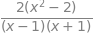

In [45]:
(2 - 2 / (x**2 - 1)).factor()

#### 괄호 전개

괄호 전개는 말 그대로 여러 항들의 곱으로 이뤄진 다항식 및 유리식에 곱을 직접 계산해서 괄호를 전개하는걸 의미합니다. 인수 분해의 반대죠.

In [46]:
expr = (16*x - 13)**3
expr

In [47]:
expr.expand()

이 `expand()` 메소드는 다른 맥락에서도 사용이 가능합니다. 바로 복소 함수의 실수부와 허수부를 나누는 맥락이에요.

In [48]:
x = sy.symbols('x', real = True) # 실수 x에 대해서,
sy.exp(I*x).expand(complex=True) # 함수 e^Ix를 전개합니다.

위와 같이 `expand()`에 매개변수 `complex = True`가 전달되면, 전개되는 함수를 복소 함수의 형태로 생각하여, 이들을 실수부와 허수부로 나눕니다.

In [49]:
x = sy.symbols('x', complex = True)
sy.exp(I*x).expand(complex=True)

그 외에도 위에서 다룬 삼각 함수의 표현들을 위한 `expand_trig()`와 완전 동일한 역할을 하기도 합니다.

차이점은 단지 `expand_trig`는 오로지 삼각비/삼각 함수의 계산 법칙만을 사용한다는거고, `expand()`는 모든걸 다 사용한다는거에요.

In [50]:
expr = (1 + sy.sin(x + y))**2
expr

이 놈에 `expand_trig()`를 이용하면,

In [51]:
sy.expand_trig(expr)

보시다시피 오로지 삼각 함수의 계산 법칙을 활용할 수 있는 $\sin(x+y)$만 전개됩니다.

그런데 `expand()` 메소드는 `expand_trig()`이 사용하는 삼각 함수의 법칙 뿐 아니라, 우리가 아는 대수적인 전개 법칙도 모두 사용합니다.

In [52]:
sy.expand(expr, trig=True)

물론 삼각 함수의 계산 법칙을 활용하고 싶다면 위와 같이 `trig =True`를 해줘야합니다. 그게 없으면 그냥 대수적인 계산으로만 전개해요

In [53]:
sy.expand(expr)

#### 변수로 묶기

보통 다항식에는 변수의 역할을 하는 친구들이 있고, 나머지는 모양이 마치 변수같더라도 상수의 역할을 하는데요,

예를 들어서 $x(y+1) + x^2y$라는 식이 있다면, 우리는 이걸 $y$에 대한 다항식으로도 생각할 수 있고, $x$에 대한 다항식으로 생각할 수 있죠. 

`collect()`메소드는 주어진 다항식을 변수로 생각할 상징에 대해서 묶어버리는 함수입니다.

```python
sy.collect(expr, symbol)
```

저렇게 사용하면, `symbol`을 기준으로 `expr`을 묶습니다. 그런데 저 `collect()`함수 혼자서는 이 과정을 우리가 의도한대로 수행하지 못할 수 있습니다.

만약 $x(y+1) + x^2y$를 $y$에 대해서 묶는다면, 우리는 다음의 결과물을 예상할겁니다.

$$
(x^2+x)y + x
$$

$y$를 변수로 보니까, y를 기준으로 앞의 계수들을 모으고, 상수항은 상수항끼리 모은 결과죠.

그런데 이를 위해서는 결국 기존의 $x(y+1) + x^2y$를 전개하는 과정이 필수적입니다. 다음과 같은 단계로 묶이는거죠.

$$
x(y+1) + x^2y \quad \overset{(*)}{\Rightarrow} \quad xy + x + x^2y \quad \Rightarrow \quad xy + x^2y + x \quad \Rightarrow \quad (x^2+x)y + x
$$

`collect()`함수는 다른 모든 과정은 수행할 수 있으나, $(*)$의 괄호를 전개하는 과정은 수행할 수 없습니다.

따라서 우리는 그냥 단순히 `sy.collect(expr, symbol)`을 사용하는 대신, `sy.collect(sy.expand(expr),symbol)`을 사용합니다 :

In [54]:
sy.collect(sy.expand(x * (y + 1) + x**2 * y), y)

전개할 능력이 없어서, 전개만 우리가 `expand()`로 대신 해주는거죠. 실제로 전개를 하지 않으면 다음과 같이 올바르게 변수를 묶을 수 없습니다.

In [55]:
sy.collect(x * (y + 1) + x**2 * y, y)

우리의 입장에서는 $x(y+1)$에도 $y$가 들어있으나, SymPy의 입장에서 $(y+1)$은 그냥 표현이라서, 저걸 상징인 $y$로 곧바로 인식하지 못합니다.

따라서 저기 있는 $x(y+1)$는 상징 $y$가 없는 상수나 다름없이 여겨져서, 저렇게 똑바로 $y$에 대해서 묶이지가 않습니다.

#### 부분 분수 분해

함수 `sy.apart()`는 복잡한 유리식을 부분 분수 분해, 즉 유리식을 풀어서 또 다른 유리식들의 합으로 표현합니다.

```python
sy.apart(expr, symbol) # symbol이 입력되지 않는 경우, 자동으로 상징을 하나 임의로 고릅니다.
```

이 때 규칙은 합으로 분해되는 모든 항에서 분자의 차수가 분모의 차수보다 낮게된다는겁니다.(동일 차수도 안됨)

그리고 차수를 따지는 기준이 되는 상징이 위의 `symbol`이 되겠습니다.

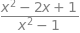

In [56]:
expr = (x**2 - 2*x + 1) / (x**2 - 1)
expr

이런 `expr`을 `apart()`하면, 그 결과는 다음과 같습니다.

In [57]:
expr.apart()

$\frac{x-1}{x+1}$로도 만들 수 있겠으나, 언급한대로 분자의 차수가 항상 분모의 차수보다 작은 형태를 만드므로, $1 - \frac{2}{x+1}$이 되는겁니다.

#### 약분

SymPy에서는 당연히 유리식의 약분도 가능합니다. 이는 `cancel()`메소드를 활용하시면 됩니다 : 

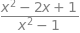

In [58]:
expr = (x**2 - 2*x + 1) / (x**2 - 1)
expr

In [59]:
expr.cancel() # 분모와 분자의 x-1을 약분함

주의할 점은 `cancel()`은 만약 대상 표현이 여러 유리식의 합의 형태라면, 이들을 일단 합친 후, 다시 약분한다는겁니다.

In [60]:
expr.apart().cancel()

따라서 원래는 $1- \frac{2}{x+1}$ 형태였던 `expr.apart()`에 `cancel()`을 사용하면 위와 같은 결과가 나오게 됩니다.

### 지수

지수의 곱에는 다음의 법칙이 있습니다.
$$
x^ax^b = x^{a+b},\quad x^ay^a = (xy)^a
$$

이 규칙을 이용하여 숫자를 단순화하는건 `powsimp()`메소드를 이용하시면 됩니다.

~~~python
expr.powsimp()
~~~

In [61]:
(sy.exp(x) * sy.exp(y)).powsimp()

## 효율적인 수치 계산

위에서 우리는 이미 치환과 평가 파트에서 상징적인 표현의 값을 수치적으로 계산하는 방법을 다뤄봤는데요,

이러한 계산 과정은 생각보다 많이 느립니다. SymPy는 상징들을 처리하는대에는 천재이지만, 계산은 좀 못하는 친구거든요. 

예를 들어 $2x$라는 간단한 표현에 $x$의 수치 1,2,...,100을 직접 넣어서 다루는 경우, 

SymPy는 $x$의 자리에 진짜 수치를 넣는 대신에, 1,2,...100이라는 상징을 하나 하나 대입하여, 최종 계산 형태가 되는 상징을 만들어내는

상징 처리 과정을 거치게 됩니다. 이렇게 하나 하나 기호처리를 하는건 생각보다 많이 느립니다.

근데 걱정하실 필요는 없어요. 

SymPy에는 SymPy를 이용해 만든 상징적인 표현을 매우 효율적으로 NumPy의 고속 계산이 가능한 함수로 변환해주는 도구가 존재합니다.

~~~python
sy.lambdify(args, expr)
~~~

`expr`은 당연히 우리가 함수화하고 싶은 상징적 표현이구요, `args`에는 그 표현에서 실제 함수의 변수로 생각할 놈들이 들어옵니다.

만약 `expr`의 여러 변수가 `args`로 사용되어야 한다면, `args`에는 그 상징들의 투플을 넣으시면 됩니다.

In [62]:
expr = sy.exp(x) + x**2
expr

예를 들어 위와 같이 `expr`에 상징적 표현이 담긴 놈을 정의하면, 

다음과 같이 `f`라는 변수 안에는 기존의 `expr`과 동일한 구조로 계산하는 NumPy의 유니버셜 함수가 들어가게 됩니다

In [63]:
f = sy.lambdify(x, expr)
f(1)

따라서 `f(1)`의 결과도 보시다시피 넘파이의 `Float` 객체로 돌아오는걸 알 수 있습니다.

혹시나 저 함수가 넘파이의 함수라서, 사용하려면 넘파이를 불러와야하지 않을까 하실 수 있는데요,

이건 `lambdify()`가 알아서 처리하기 떄문에, 그럴 필요는 없습니다.

이 `lambdify()`가 뱉어내는 함수는 유니버셜 함수이기 떄문에, 리스트나 배열 등에 직접적으로 사용하는 게 가능합니다.

In [64]:
import numpy as np
X = np.linspace(0, 1, 10000)
f(X)

array([1.        , 1.00010003, 1.00020008, ..., 3.71733817, 3.71780998,
       3.71828183], shape=(10000,))

물론 이렇게 리스트를 넣더라도 결과물은 넘파이의 배열이 됩니다.

이렇게 유니버셜 함수가 된 `f`는 수치적 계산에서 단순 상징에 치환하는거보다 훨씬 더 빠르고, 엘레강스한 결과물들을 줍니다.

이 `f`에 `help(f)` 혹은 `f?`를 해보신다면, 이 놈이 어떤 식으로 구성되어있는지도 정확히 나옵니다 :

In [65]:
help(f)

Help on function _lambdifygenerated:

_lambdifygenerated(x)
    Created with lambdify. Signature:

    func(x)

    Expression:

    x**2 + exp(x)

    Source code:

    def _lambdifygenerated(x):
        return x**2 + exp(x)


    Imported modules:



위 설명에서 `exp` 는 당연히 `sympy.exp`가 아닌, `numpy.exp`입니다.

이 `lambdify()`에도 한계점은 있습니다. 이 놈은 완벽하게 SymPy를 상징을 NumPy로 넘기지는 못합니다.

예를 들어 만약 우리의 심파이 함수가 조각별로 정의된다면, 이 놈은 `numpy.select`라는 함수의 형태로 변환되는데요,

`numpy.select`는 우선 주어진 표현들을 다 모든 범위에서 계산하고, 조건에 맞는 친구들만 골라서 함수를 구성시킵니다.

우리는 일반적으로 우선 범위를 보고, 그 범위에 있는 값들에 대해서만 함수값을 계산할텐데 말이죠.

따라서 일단 기본적으로 매우 비효율적이구요, 심지어 운이 좋지 않다면 완전 다른 함수를 만들어낼 수도, 뭔가 지뢰를 포함하는 함수를 만들어낼 수도 있습니다.

In [66]:
expr = sy.Piecewise(
    (1 / (x - 1), x < 0),
    (1,           True)
)
expr

⎧  1             
⎪─────  for x < 0
⎨x - 1           
⎪                
⎩  1    otherwise

위 함수는 음수의 범위에서는 $\frac{1}{x-1}$, 0보다 크거나 같은 범위에서는 1의 값을 가지는 함수입니다.

여기까진 아무런 문제가 없죠. 우리의 상식 선에서는 위의 함수는 실수 전체에서 잘 정의됩니다.

In [67]:
expr.subs(x, 1)

그리고 1을 집어넣는다면, 위와 같이 1이라는 값이 나옵니다.

그런데 저 `expr`을 다음과 같이 `lambdify()`하여 NumPy의 함수로 만들어버린다면,

In [68]:
f = sy.lambdify(x, expr)
print(f.__doc__)

Created with lambdify. Signature:

func(x)

Expression:

Piecewise((1/(x - 1), x < 0), (1, True))

Source code:

def _lambdifygenerated(x):
    return select([less(x, 0),True], [(x - 1)**(-1.0),1], default=nan)


Imported modules:




위와 같이 얼핏보면 잘 `select`함수로 생성된거 같아 보이지만, 값에 접근할 떄 문제가 발생합니다. 위에서 했던대로 1에서의 값을 생각해보죠.

In [69]:
f(1)

<class 'ZeroDivisionError'>: 0.0 cannot be raised to a negative power

그러면 보시다시피, 설명한대로 NumPy는 조건문을 확인하기 이전에 먼저 모든 주어진 표현에 대해 값을 계산하기 떄문에, 

우리의  $\frac{1}{x-1}$에도 1을 집어넣으려고 합니다. 따라서 이 과정에서 $\frac{1}{0}$이 발생하여, 

위와 같이 `ZeroDivisionError`라는 익셉션이 레이즈됩니다.

In [70]:
f(-1)

array(-0.5)

물론 다른 경우에는 전혀 문제가 없는데요, 저렇게 지뢰가 숨어있을 수도 있다는겁니다.